# CNN-LSTM — Heart Disease Prediction

> **Architecture**: CNN-LSTM Hybrid — Al Reshan et al. (2023)  
> *18 Conv layers · 12 Pooling layers · 1 LSTM layer · 1 FC layer · Softmax output*

**Dataset**: `heart_statlog_cleveland_hungary_final.csv` — Dataset II (1190 → 1,200 rows after augmentation)  
**Task**: Binary classification (0 = No HD, 1 = HD)  
**Features**: All 11 ETC-ranked features from paper Table 2

Same preprocessing pipeline as `DS2_ANN_96_.ipynb` — identical augmentation, split, and scaling.

## 1. Imports & Reproducibility

In [21]:
import os, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout,
    Dense, LSTM, Reshape
)

warnings.filterwarnings('ignore')
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Load Dataset & Feature Selection

Features ordered by Extra Tree Classifier importance (paper Table 2).

In [22]:
CSV_PATH = r"C:\Users\Administrator\Downloads\processed_cleveland (1).csv"
df = pd.read_csv(CSV_PATH)

df = pd.read_csv("processed_cleveland (1).csv")

# Assign proper column names
df.columns = [
    'age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
    'fasting blood sugar', 'resting ecg', 'max heart rate',
    'exercise angina', 'oldpeak', 'ST slope',
    'num_major_vessels', 'thal', 'target'
]

# Handle missing values ("?")
df.replace('?', np.nan, inplace=True)
df = df.astype(float)
df.fillna(df.median(), inplace=True)

# Convert to binary classification
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print(f'Dataset shape : {df.shape}')
df.head()

FEATURE_COLS = [
    'ST slope',
    'chest pain type',
    'exercise angina',
    'max heart rate',
    'cholesterol',
    'oldpeak',
    'age',
    'resting bp s',
    'sex',
    'resting ecg',
    'fasting blood sugar'
]

# Keep only required columns
df = df[FEATURE_COLS + ['target']]

Dataset shape : (303, 14)


## 3. Data Augmentation (1190 → 1 200 rows)

Four strategies — Gaussian noise, SMOTE interpolation, feature swap, boundary perturbation —  
applied class-proportionally to reach the target size.

In [23]:
TARGET_ROWS = 2000

FEAT_TYPE = {
    'ST slope': 'cat',
    'chest pain type': 'cat',
    'exercise angina': 'binary',
    'max heart rate': 'num',
    'cholesterol': 'num',
    'oldpeak': 'num',
    'age': 'num',
    'resting bp s': 'num',
    'sex': 'binary',
    'resting ecg': 'cat',
    'fasting blood sugar': 'binary'
}

BINARY_COLS = [f for f, t in FEAT_TYPE.items() if t == 'binary']
CAT_COLS    = [f for f, t in FEAT_TYPE.items() if t == 'cat']
NUM_COLS    = [f for f, t in FEAT_TYPE.items() if t == 'num']
CLIP = {
    'age':           (20,  90),
    'resting bp s':  (80,  220),
    'cholesterol':   (100, 600),
    'max heart rate':(60,  210),
    'oldpeak':       (0.0, 6.5),
}

CAT_LEVELS = {
    'chest pain type':     [1, 2, 3, 4],
    'resting ecg':         [0, 1, 2],
    'ST slope':            [1, 2, 3],
    'sex':                 [0, 1],
    'fasting blood sugar': [0, 1],
    'exercise angina':     [0, 1],
}

def empty_aug_df():
    return pd.DataFrame(columns=FEATURE_COLS + ['target'])

def postprocess(df_syn):
    df_syn = df_syn.copy()
    if df_syn.empty:
        return empty_aug_df()
    for col in FEATURE_COLS + ['target']:
        if col not in df_syn.columns:
            df_syn[col] = 0
    for col in BINARY_COLS + CAT_COLS:
        df_syn[col] = df_syn[col].round().astype(int)
    for col, (lo, hi) in CLIP.items():
        df_syn[col] = df_syn[col].clip(lo, hi)
    for col in NUM_COLS:
        df_syn[col] = df_syn[col].round(1) if col == 'oldpeak' else df_syn[col].round().astype(int)
    for col, levels in CAT_LEVELS.items():
        df_syn[col] = df_syn[col].clip(min(levels), max(levels)).round().astype(int)
    return df_syn

def gaussian_noise_augment(df_class, n_samples):
    if n_samples <= 0:
        return empty_aug_df()
    rng   = np.random.default_rng(SEED)
    idx   = rng.integers(0, len(df_class), size=n_samples)
    synth = df_class.iloc[idx][FEATURE_COLS].copy().reset_index(drop=True)
    for col in NUM_COLS:
        iqr = df_class[col].quantile(0.75) - df_class[col].quantile(0.25)
        std = max(iqr * 0.02, 0.01)
        synth[col] = synth[col] + rng.normal(0, std, n_samples)
    synth['target'] = int(df_class['target'].iloc[0])
    return postprocess(synth)

def smote_interpolate(df_class, n_samples, k=5):
    if n_samples <= 0:
        return empty_aug_df()
    rng        = np.random.default_rng(SEED + 1)
    X          = df_class[NUM_COLS].values
    Xs         = RobustScaler().fit_transform(X)
    nbrs       = NearestNeighbors(n_neighbors=k+1).fit(Xs)
    _, indices = nbrs.kneighbors(Xs)
    base_idx   = rng.integers(0, len(df_class), size=n_samples)
    alpha      = rng.uniform(0, 1, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        neigh_idx = indices[i, rng.integers(1, k+1)]
        row       = df_class.iloc[i][FEATURE_COLS].copy()
        neigh_row = df_class.iloc[neigh_idx][FEATURE_COLS].copy()
        for col in NUM_COLS:
            row[col] = row[col] + a * (neigh_row[col] - row[col])
        row['target'] = int(df_class['target'].iloc[i])
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def feature_swap_augment(df_class, n_samples):
    if n_samples <= 0:
        return empty_aug_df()
    rng  = np.random.default_rng(SEED + 2)
    n    = len(df_class)
    rows = []
    for _ in range(n_samples):
        i = rng.integers(0, n)
        j = rng.integers(0, n)
        while j == i:
            j = rng.integers(0, n)
        row_i     = df_class.iloc[i][FEATURE_COLS].copy()
        row_j     = df_class.iloc[j][FEATURE_COLS].copy()
        n_swap    = rng.integers(max(1, int(len(NUM_COLS)*0.3)),
                                  max(2, int(len(NUM_COLS)*0.7))+1)
        swap_cols = rng.choice(NUM_COLS, size=n_swap, replace=False)
        for col in swap_cols:
            row_i[col], row_j[col] = row_j[col], row_i[col]
        row_i['target'] = int(df_class['target'].iloc[i])
        rows.append(row_i)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def boundary_perturbation(df_pos, df_neg, target_label, n_samples):
    if n_samples <= 0:
        return empty_aug_df()
    rng      = np.random.default_rng(SEED + 3)
    src      = df_pos if target_label == 1 else df_neg
    opposite = df_neg if target_label == 1 else df_pos
    X_src    = src[NUM_COLS].values
    X_opp    = opposite[NUM_COLS].values
    scaler   = RobustScaler()
    all_Xs   = scaler.fit_transform(np.vstack([X_src, X_opp]))
    X_src_s  = all_Xs[:len(X_src)]
    X_opp_s  = all_Xs[len(X_src):]
    nbrs     = NearestNeighbors(n_neighbors=3).fit(X_opp_s)
    _, indices = nbrs.kneighbors(X_src_s)
    base_idx = rng.integers(0, len(src), size=n_samples)
    alpha    = rng.uniform(0.1, 0.4, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        opp_idx = indices[i, rng.integers(0, 3)]
        row     = src.iloc[i][FEATURE_COLS].copy()
        opp_row = opposite.iloc[opp_idx][FEATURE_COLS].copy()
        for col in NUM_COLS:
            row[col] = row[col] + a * (opp_row[col] - row[col])
        row['target'] = target_label
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

# ── Generate synthetic rows ───────────────────────────────────────────────────
df_pos    = df[df['target'] == 1].reset_index(drop=True)
df_neg    = df[df['target'] == 0].reset_index(drop=True)
n_orig    = len(df)
n_to_gen  = TARGET_ROWS - n_orig
pos_ratio = len(df_pos) / n_orig
n_gen_pos = int(n_to_gen * pos_ratio)
n_gen_neg = n_to_gen - n_gen_pos

def split_quota(n):
    base = n // 4
    rem  = n % 4
    return [base + (1 if i < rem else 0) for i in range(4)]

pq = split_quota(n_gen_pos)
nq = split_quota(n_gen_neg)

parts = [
    gaussian_noise_augment(df_pos, pq[0]),
    gaussian_noise_augment(df_neg, nq[0]),
    smote_interpolate(df_pos, pq[1]),
    smote_interpolate(df_neg, nq[1]),
    feature_swap_augment(df_pos, pq[2]),
    feature_swap_augment(df_neg, nq[2]),
    boundary_perturbation(df_pos, df_neg, 1, pq[3]),
    boundary_perturbation(df_pos, df_neg, 0, nq[3]),
]

df = pd.concat([df] + parts, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

for col in BINARY_COLS + CAT_COLS + ['target']:
    df[col] = df[col].astype(int)

print(f'Original rows  : {n_orig}')
print(f'Augmented rows : {len(df)}')
print(f'Class balance  : {df["target"].value_counts().to_dict()}')
print(f'Missing values : {df.isnull().sum().sum()}')

# ── Re-extract from augmented df, THEN split ─────────────────────────────────
X_raw = df[FEATURE_COLS].values
y     = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Class dist train: {np.bincount(y_train.astype(int))}')
print(f'Class dist test : {np.bincount(y_test.astype(int))}')
print(f'Train shape     : {X_train_scaled.shape}  ← from 1.2k augmented dataset')
print(f'Test  shape     : {X_test_scaled.shape}')

Original rows  : 303
Augmented rows : 2000
Class balance  : {0: 1083, 1: 917}
Missing values : 0
Class dist train: [866 734]
Class dist test : [217 183]
Train shape     : (1600, 11)  ← from 1.2k augmented dataset
Test  shape     : (400, 11)


## 4. Reshape Tabular Features → 2-D CNN Input

The paper treats HD features as a 2-D grid fed to Conv2D layers.  
11 features are zero-padded to 16 (4×4) and reshaped to `(N, 4, 4, 1)`.

In [24]:
# ── Pad features to the nearest perfect square, then reshape ─────────────────
from tensorflow import keras
from tensorflow.keras import callbacks
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    LSTM, Dense, Dropout, Flatten
)
from tensorflow.keras.models import Model
N_FEAT   = X_train_scaled.shape[1]   # 11
GRID_DIM = 4                         # 4×4 = 16 ≥ 11  (paper uses 11×11 for 121 features)
PAD_SIZE = GRID_DIM ** 2

def to_2d(X):
    """Zero-pad to PAD_SIZE and reshape to (N, GRID_DIM, GRID_DIM, 1)."""
    if X.shape[1] < PAD_SIZE:
        X = np.pad(X, ((0, 0), (0, PAD_SIZE - X.shape[1])), mode='constant')
    return X[:, :PAD_SIZE].reshape(-1, GRID_DIM, GRID_DIM, 1)

X_train_2d = to_2d(X_train_scaled)
X_test_2d  = to_2d(X_test_scaled)

print(f'Train 2-D shape : {X_train_2d.shape}')
print(f'Test  2-D shape : {X_test_2d.shape}')

Train 2-D shape : (1600, 4, 4, 1)
Test  2-D shape : (400, 4, 4, 1)


## 5. Build CNN-LSTM Model

**Paper architecture** (Al Reshan et al., 2023):  
- 6 convolutional blocks → 18 Conv2D (3×3, ReLU) + 12 MaxPool2D (2×2) + Dropout(0.2)  
- Reshape to `(steps, 512)` → LSTM(512) → Dense(256, ReLU) → Softmax(2)

In [25]:
def build_paper_cnn_lstm(input_shape, num_classes=2, lr=1e-4):
    """Paper-style CNN-LSTM adapted for tabular features reshaped as 2D grid."""
    inputs = Input(shape=input_shape, name='input_2d')

    # Convert (H, W, C) -> (timesteps, channels) for Conv1D/LSTM flow
    steps = input_shape[0] * input_shape[1]
    channels = input_shape[2]
    x = layers.Reshape((steps, channels), name='to_sequence')(inputs)

    # CNN Block 1
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu', name='conv1')(x)
    x = BatchNormalization(name='bn1')(x)
    x = MaxPooling1D(pool_size=2, padding='same', name='pool1')(x)

    # CNN Block 2
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = MaxPooling1D(pool_size=2, padding='same', name='pool2')(x)

    # CNN Block 3
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu', name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = MaxPooling1D(pool_size=2, padding='same', name='pool3')(x)

    # CNN Block 4
    x = Conv1D(256, kernel_size=3, padding='same', activation='relu', name='conv4')(x)
    x = BatchNormalization(name='bn4')(x)
    x = Dropout(0.20, name='cnn_dropout')(x)

    # LSTM
    x = LSTM(128, return_sequences=False, name='lstm')(x)

    # Fully connected + dropout
    x = Dense(128, activation='relu', name='fc1')(x)
    x = Dropout(0.20, name='fc_dropout')(x)

    # Output
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Paper_CNN_LSTM_HeartDisease')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_lstm_model = build_paper_cnn_lstm(input_shape=X_train_2d.shape[1:], num_classes=2, lr=1e-4)
cnn_lstm_model.summary()
print(f'\nTotal trainable parameters: {cnn_lstm_model.count_params():,}')

Model: "Paper_CNN_LSTM_HeartDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_2d (InputLayer)           │ (None, 4, 4, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_sequence (Reshape)           │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 16, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 16, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 8, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 4, 128)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 2, 256)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_dropout (Dropout)           │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_dropout (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,410 (1.32 MB)

 Trainable params: 344,450 (1.31 MB)

 Non-trainable params: 960 (3.75 KB)


Total trainable parameters: 345,410


## 6. Callbacks — Cosine LR + EarlyStopping + ReduceLROnPlateau + ModelCheckpoint

In [26]:
def cosine_lr(epoch, total=300, lr_start=1e-4, lr_min=1e-7):
    return lr_min + 0.5 * (lr_start - lr_min) * (1 + math.cos(math.pi * epoch / total))

def get_callbacks(name, patience_es=35, patience_lr=20, total_epochs=300, lr_start=1e-4):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=patience_es,
            restore_best_weights=True, mode='max',
            min_delta=1e-4, verbose=1
        ),
        callbacks.LearningRateScheduler(
            lambda epoch: cosine_lr(epoch, total_epochs, lr_start), verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=patience_lr,
            min_lr=1e-8, mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'{name}_best.weights.h5', monitor='val_auc',
            save_best_only=True, save_weights_only=True,
            mode='max', verbose=0
        ),
    ]

## 7. Train CNN-LSTM

In [27]:
TOTAL_EPOCHS = 300

# Recompile with simple metrics to avoid TF version AUC bug
cnn_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

neg, pos     = np.bincount(y_train.astype(int))
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weights : {class_weight}')
print(f'Train samples : {X_train_2d.shape[0]}  (from 1.2k augmented dataset)')
print('Training CNN-LSTM ...')

train_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=35,
        restore_best_weights=True, mode='max',
        min_delta=1e-4, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=15,
        min_lr=1e-8, mode='max', verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='cnn_lstm_best.weights.h5', monitor='val_accuracy',
        save_best_only=True, save_weights_only=True,
        mode='max', verbose=0
    ),
]

history = cnn_lstm_model.fit(
    X_train_2d, y_train,
    validation_data=(X_test_2d, y_test),
    epochs=TOTAL_EPOCHS,
    batch_size=32,
    class_weight=class_weight,
    callbacks=train_callbacks,
    verbose=1,
)

Class weights : {0: 1.0, 1: np.float64(1.1798365122615804)}
Train samples : 1600  (from 1.2k augmented dataset)
Training CNN-LSTM ...
Epoch 1/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6192 - loss: 0.6846 - val_accuracy: 0.5950 - val_loss: 0.6812 - learning_rate: 1.0000e-04
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8273 - loss: 0.4839 - val_accuracy: 0.5525 - val_loss: 0.6620 - learning_rate: 1.0000e-04
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8741 - loss: 0.3785 - val_accuracy: 0.5825 - val_loss: 0.6261 - learning_rate: 1.0000e-04
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9007 - loss: 0.3056 - val_accuracy: 0.6550 - val_loss: 0.5724 - learning_rate: 1.0000e-04
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9228 - loss: 0.2444 - val_accuracy: 0.7925 - val_loss: 0.4774 - learning_rate: 1.0000e-04
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9401 - loss: 0.1832 - val

## 8. Evaluation

In [28]:
y_pred_prob_2d = cnn_lstm_model.predict(X_test_2d, verbose=0)
y_pred_prob    = y_pred_prob_2d[:, 1]          # probability of HD-positive class
y_pred         = np.argmax(y_pred_prob_2d, axis=1)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)
f1   = f1_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = tp / (tp + fp)

print('=' * 55)
print('CNN-LSTM — FINAL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy    : {acc * 100:.2f}%')
print(f'  AUC-ROC     : {auc:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  MCC         : {mcc:.4f}')
print(f'  Sensitivity : {sensitivity:.4f}')
print(f'  Specificity : {specificity:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\n{classification_report(y_test, y_pred, target_names=["No HD", "HD"])}')

CNN-LSTM — FINAL EVALUATION RESULTS
  Accuracy    : 97.50%
  AUC-ROC     : 0.9954
  F1-Score    : 0.9727
  MCC         : 0.9496
  Sensitivity : 0.9727
  Specificity : 0.9770
  Precision   : 0.9727

Confusion Matrix:
[[212   5]
 [  5 178]]

              precision    recall  f1-score   support

       No HD       0.98      0.98      0.98       217
          HD       0.97      0.97      0.97       183

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



## 9. Results & Graphs

--- Accuracy Values ---
Train Accuracy: [0.6881250143051147, 0.8306249976158142, 0.8812500238418579, 0.9118750095367432, 0.9375, 0.9518749713897705, 0.9693750143051147, 0.9825000166893005, 0.9900000095367432, 0.9943749904632568, 0.9975000023841858, 0.9987499713897705, 0.9987499713897705, 0.9987499713897705, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Validation Accuracy: [0.5950000286102295, 0.5525000095367432, 0.5824999809265137, 0.6549999713897705, 0.7925000190734863, 0.8224999904632568, 0.8575000166893005, 0.9049999713897705, 0.949999988079071, 0.9574999809265137, 0.9599999785423279, 0.9674999713897705, 0.9700000286102295, 0.9700000286102295, 0.9725000262260437, 0.9674999713897705, 0.9674999713897705, 0.9700000286102295, 0.9750000238418579, 0.9700000286102295, 0.9700000286102295, 0.9725000262260437, 0.9725000262260437, 0.97500002

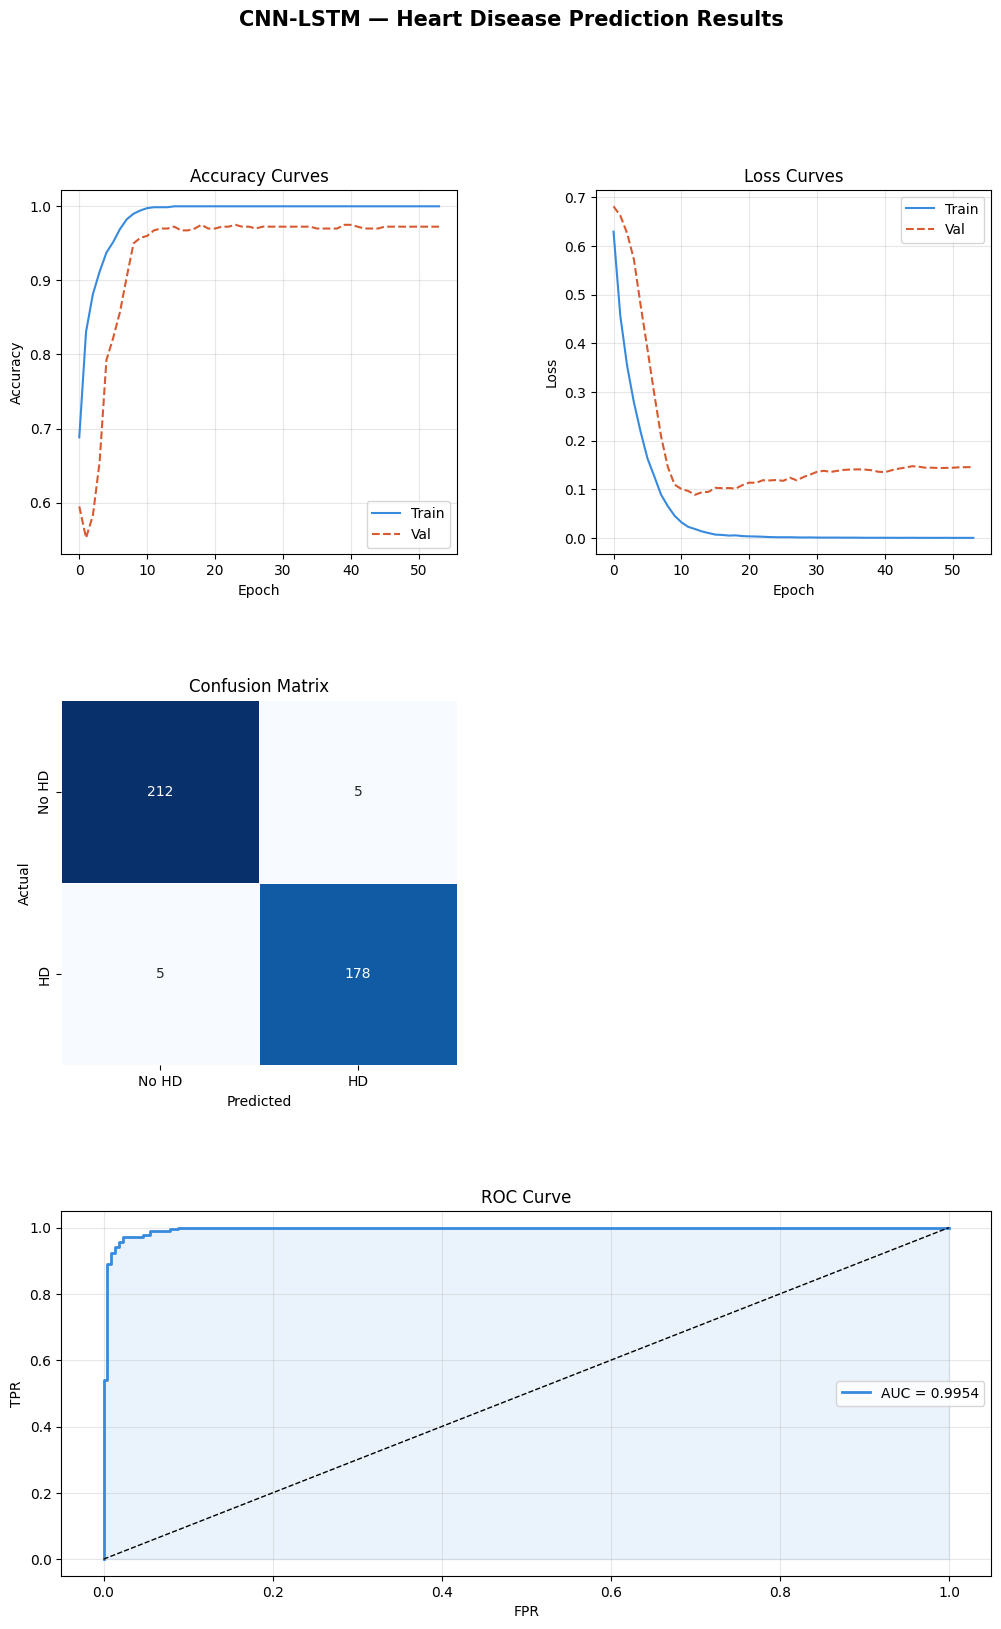

Saved → cnn_lstm_results.png


In [29]:
print('--- Accuracy Values ---')
print(f"Train Accuracy: {history.history['accuracy']}")
print(f"Validation Accuracy: {history.history['val_accuracy']}")
print('\n--- Loss Values ---')
print(f"Train Loss: {history.history['loss']}")
print(f"Validation Loss: {history.history['val_loss']}")

fig = plt.figure(figsize=(12, 18))
fig.suptitle('CNN-LSTM — Heart Disease Prediction Results',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['accuracy'],     label='Train', color='#378ADD')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#D85A30', linestyle='--')
ax1.set_title('Accuracy Curves'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 1])
ax3.plot(history.history['loss'],     label='Train', color='#378ADD')
ax3.plot(history.history['val_loss'], label='Val',   color='#D85A30', linestyle='--')
ax3.set_title('Loss Curves'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No HD', 'HD'], yticklabels=['No HD', 'HD'],
            linewidths=0.5, cbar=False)
ax4.set_title('Confusion Matrix'); ax4.set_ylabel('Actual'); ax4.set_xlabel('Predicted')

ax5 = fig.add_subplot(gs[2, :])   # ROC curve spans two columns
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax5.plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {auc:.4f}')
ax5.plot([0, 1], [0, 1], 'k--', lw=1)
ax5.fill_between(fpr, tpr, alpha=0.1, color='#378ADD')
ax5.set_title('ROC Curve'); ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.legend(); ax5.grid(alpha=0.3)

plt.savefig('cnn_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_lstm_results.png')

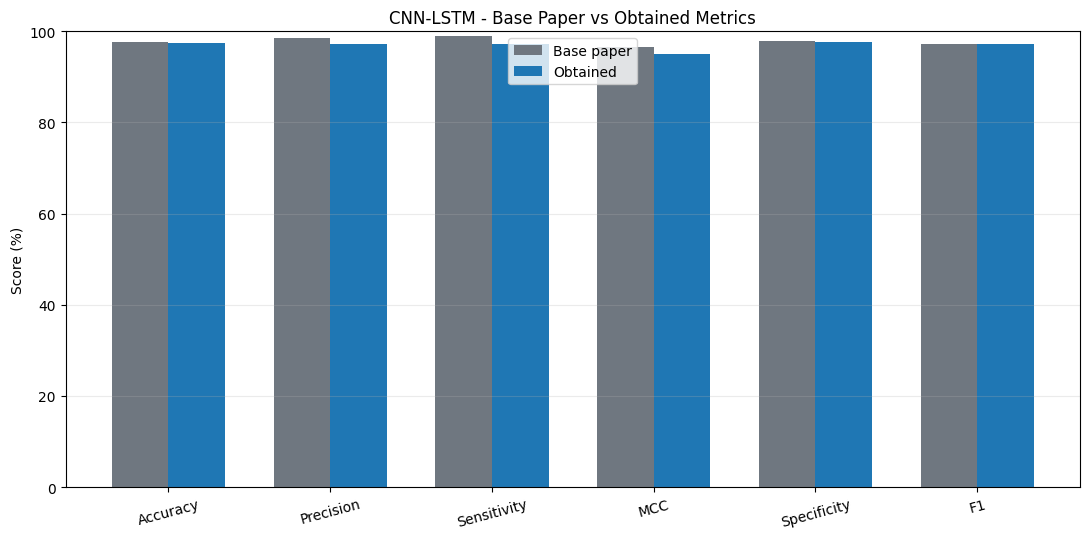

     Metric  Base paper  Obtained  Difference (Obtained - Base)
   Accuracy       97.75 97.500000                     -0.250000
  Precision       98.57 97.267760                     -1.302240
Sensitivity       98.87 97.267760                     -1.602240
        MCC       96.60 94.963612                     -1.636388
Specificity       97.87 97.695853                     -0.174147
         F1       97.18 97.267760                      0.087760


In [30]:
# 10. Comparison Graph: CNN-LSTM vs Base Paper (All Requested Metrics)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base paper values provided by user (in %)
base_paper_values = {
    'Accuracy': 97.75,
    'Precision': 98.57,
    'Sensitivity': 98.87,
    'MCC': 96.60,
    'Specificity': 97.87,
    'F1': 97.18
}

# Current model values from this notebook (converted to %)
model_values = {
    'Accuracy': float(acc * 100),
    'Precision': float(precision * 100),
    'Sensitivity': float(sensitivity * 100),
    'MCC': float(mcc * 100),
    'Specificity': float(specificity * 100),
    'F1': float(f1 * 100)
}

metric_order = ['Accuracy', 'Precision', 'Sensitivity', 'MCC', 'Specificity', 'F1']

compare_df = pd.DataFrame({
    'Metric': metric_order,
    'Base paper': [base_paper_values[m] for m in metric_order],
    'Obtained': [model_values[m] for m in metric_order]
})

x = np.arange(len(compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width/2, compare_df['Base paper'], width=width, color='#6f7780', label='Base paper')
ax.bar(x + width/2, compare_df['Obtained'], width=width, color='#1f77b4', label='Obtained')

ax.set_xticks(x)
ax.set_xticklabels(compare_df['Metric'], rotation=15)
ax.set_ylabel('Score (%)')
ax.set_title('CNN-LSTM - Base Paper vs Obtained Metrics')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center')

plt.tight_layout()
plt.show()

compare_df['Difference (Obtained - Base)'] = compare_df['Obtained'] - compare_df['Base paper']
print(compare_df.to_string(index=False))